In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.io as pio
import IPython

pd.set_option('display.max_columns', None)

# Data Loading

In [2]:
DATA_PATH = "results/MAG2P_order_parameters-2025-12-8-16:13:13.pickle"

dg = pd.read_pickle(DATA_PATH)
df = dg.fillna(0)
df = df.drop(columns=["std_bonds_1_8", "std_bonds_1_5", "std_size",
                       "std_radius_of_gyration", "std_second_neighbours"])
df = df.loc[:, (df != 0).any(axis=0)]

print(f"Loaded {len(df)} rows, {len(df.columns)} columns")
df.head()

Loaded 2760 rows, 87 columns


/tmp/ipykernel_891341/1699651328.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = dg.fillna(0)


,file_id,lambda,shift,mean_bonds_1_8,mean_bonds_1_5,mean_second_neighbours,mean_size,largest,mean_radius_of_gyration,0.125664,0.251327,0.376991,0.502655,0.628319,0.753982,0.879646,1.00531,1.130973,1.256637,1.382301,1.507964,1.633628,1.759292,1.884956,2.010619,2.136283,2.261947,2.38761,2.513274,2.638938,2.764602,2.890265,3.015929,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,1.1,1.3,1.5,1.7,1.9,2.1,2.3,2.5,2.7,2.9,3.1,3.3,3.5,3.7,3.9,4.1,4.3,4.5,4.7,4.9,5.1,5.3,5.5,5.7,5.9
0,mag2p_shift_0.15_lambda_30_phi2d_0.0106_rid_1/,30.0,0.15,1.726,1.726,0.0,7.587786,32,3.503756,3.476328,1.364712,0.184421,0.009221,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.155463,0.416339,0.766414,1.229084,1.816968,2.479134,3.263851,4.112634,5.120903,5.905970,7.207076,8.649195,9.855037,9.300543,12.406700,12.112959,0.000000,18.315904,0.000000,0.000000,24.949207,0.000000,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,123.785408,0.0,0.000000,0.000000,0.000000,0.394341,23.738146,0.000000,0.000000,0.000000,0.036207,9.713634,0.000000,0.000000,0.000000,0.041404,0.451716,3.875424,0.000000,0.014495,0.033451,0.086729,2.209009,0.010712,0.000000
1,mag2p_shift_0.35_lambda_40_phi2d_0.0106_rid_8/,40.0,0.35,1.740,1.740,0.0,6.847222,27,2.792470,2.945281,1.271410,0.466489,0.192084,0.219524,0.182937,0.164643,0.064028,0.118909,0.164643,0.027441,0.009147,0.009147,0.027441,0.036587,0.009147,0.009147,0.018294,0.000000,0.009147,0.000000,0.000000,0.000000,0.000000,0.156924,0.418694,0.785033,0.454389,0.589194,2.448045,1.069686,4.082124,5.121499,5.917206,6.880607,8.575021,9.170284,0.000000,11.239750,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,26.61778,0.0,0.0,0.0,124.789459,0.0,0.077235,1.082712,1.685773,3.509636,19.694113,0.278309,0.835182,0.724000,0.380175,8.275761,0.042609,0.152515,0.022879,0.062106,0.856378,2.655224,0.023632,0.014495,0.033451,0.198237,1.622241,0.005356,0.019996
2,mag2p_shift_0.5_lambda_25_phi2d_0.0106_rid_8/,25.0,0.50,2.244,2.244,0.0,5.824561,21,1.081621,0.014185,0.014185,0.014185,0.000000,0.021277,0.000000,0.170219,0.524843,0.290791,0.170219,0.234051,0.290791,0.397178,0.290791,0.801449,2.014260,1.141887,0.461010,0.226959,0.276606,0.170219,0.219866,0.156034,0.056740,0.160079,0.416049,0.445913,0.813668,1.313734,1.427460,0.934960,1.150697,1.383118,1.352940,4.576868,1.607531,0.000000,8.573242,5.781242,0.000000,0.000000,0.000000,0.000000,7.810187,0.000000,0.000000,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,160.935379,0.0,8.186895,3.127833,4.383009,16.049683,9.830617,1.196729,1.049943,1.282515,2.534503,4.313620,0.284063,0.393996,0.366070,0.879839,0.846968,0.524170,0.110282,0.239167,0.133805,0.328331,0.310642,0.069629,0.089984
3,mag2p_shift_0.65_lambda_50_phi2d_0.0106_rid_7/,50.0,0.65,1.714,1.714,0.0,6.104294,18,2.350347,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.046428,0.510707,0.139284,0.000000,0.000000,0.000000,0.009286,0.204283,2.367824,4.679935,0.154667,0.414145,0.769728,1.228363,1.792840,2.451360,2.700541,3.556798,5.077178,6.158384,7.291809,8.621044,5.867224,11.408399,12.953466,12.297338,16.589534,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,122.924782,0.0,0.000000,0.000000,0.096330,3.075861,19.924259,0.000000,0.047725,0.124114,0.398279,8.084044,0.014203,0.012710,0.125837,0.165617,0.489359,2.895827,0.015755,0.108712,0.066903,0.099119,1.627993,0.032136,0.074987
4,mag2p_shift_0.6_lambda_35_phi2d_0.0106_rid_3/,35.0,0.60,1.754,1.754,0.0,5.818713,23,1.876992,0.009074,0.009074,0.000000,0.000000,0.000000,0.000000,0.036295,0.045369,0.045369,0.000000,0.027221,0.072591,0.009074,0.009074,0.145181,0.671463,0.326658,0.000000,0.000000,0.018148,0.099812,0.943678,2.622336,2.867330,0.154442,0.415638,0.778697,1.234867,1.817944,2.483886,1.491917,2.756248,2.193381,4.298783,0.000000,6.543127,7.

# Feature Groups & Test Sets

In [3]:
# Define named feature groups by column index ranges
# Columns 0-2: file_id, lambda, shift (not features)
# Columns 3-8: global structural measures
# Columns 9-32: orientation (24 angular bins)
# Columns 33-61: radius of gyration (29 bins)
# Columns 62-86: g(r) (25 radial distance bins)

FEATURE_GROUPS = {
    "global":      df.columns[3:9],
    "orientation": df.columns[9:33],
    "Rg":          df.columns[33:62],
    "gofr":        df.columns[62:],
}

# Define test sets: name -> list of groups to KEEP
TEST_SETS = {
    "all_features":        list(FEATURE_GROUPS.keys()),
    "no_functions":        ["global"],
    "no_orientation_Rg":   ["global", "gofr"],
    "no_orientation_gofr": ["global", "Rg"],
    "no_Rg_gofr":          ["global", "orientation"],
    "no_global_Rg":        ["orientation", "gofr"],
    "no_orientation":      ["global", "Rg", "gofr"],
    "no_Rg":               ["global", "orientation", "gofr"],
}

# Print summary
for name, groups in TEST_SETS.items():
    n_cols = sum(len(FEATURE_GROUPS[g]) for g in groups)
    print(f"{name:25s} -> {groups}  ({n_cols} features)")

all_features              -> ['global', 'orientation', 'Rg', 'gofr']  (84 features)
no_functions              -> ['global']  (6 features)
no_orientation_Rg         -> ['global', 'gofr']  (31 features)
no_orientation_gofr       -> ['global', 'Rg']  (35 features)
no_Rg_gofr                -> ['global', 'orientation']  (30 features)
no_global_Rg              -> ['orientation', 'gofr']  (49 features)
no_orientation            -> ['global', 'Rg', 'gofr']  (60 features)
no_Rg                     -> ['global', 'orientation', 'gofr']  (55 features)


# Diffusion Map Analysis

In [4]:
import hdbscan
import seaborn as sns
import cmasher as cmr
from sklearn.manifold import SpectralEmbedding
from matplotlib.colors import ListedColormap, rgb2hex


def run_diffusion_heatmap(X, lambdas, shifts, set_name, cluster_min_size=10):
    """
    Perform Diffusion Maps on data X, assign clusters with HDBSCAN,
    and create heatmaps over (shift, lambda) space.
    Outputs are saved with set_name suffix.
    """
    embedding = SpectralEmbedding(
        n_components=2, affinity='nearest_neighbors', n_neighbors=32
    )
    diffmap_emb = embedding.fit_transform(X)
    cluster_labels = hdbscan.HDBSCAN(
        min_cluster_size=cluster_min_size, core_dist_n_jobs=-1
    ).fit_predict(diffmap_emb)

    df_cluster = pd.DataFrame({
        'lambda': lambdas,
        'shift': shifts,
        'cluster': cluster_labels,
        'Diff-1': diffmap_emb[:, 0],
        'Diff-2': diffmap_emb[:, 1],
    })

    # Color map: distinct colors for clusters, gray for noise
    unique_clusters = sorted(df_cluster['cluster'].unique())
    non_noise = [cl for cl in unique_clusters if cl != -1]
    palette = cmr.chroma(np.linspace(0, 1, max(len(non_noise), 1)))
    hex_colors = [rgb2hex(c) for c in palette]
    color_map = {str(cl): hex_colors[i] for i, cl in enumerate(non_noise)}
    color_map['-1'] = '#A0A0A0'

    # Diffusion Map scatter
    fig = px.scatter(
        df_cluster, x='Diff-1', y='Diff-2',
        color=df_cluster['cluster'].astype(str),
        hover_data={'lambda': True, 'shift': True},
        title=f'Diffusion Map - {set_name}',
        color_discrete_map=color_map,
    )
    fig.write_html(f'diffmap_clusters_{set_name}.html')
    fig.show()

    # Discrete cluster heatmap
    heatmap_data = df_cluster.groupby(['lambda', 'shift'])['cluster'] \
                             .agg(lambda x: x.value_counts().idxmax()) \
                             .unstack().sort_index(ascending=False)

    unique_hm = sorted(heatmap_data.stack().dropna().unique())
    non_noise_hm = [cl for cl in unique_hm if cl != -1]
    colors = cmr.chroma(np.linspace(0, 1, max(len(non_noise_hm), 1)))
    colors_hex = [rgb2hex(c) for c in colors]
    colors_all = ['#A0A0A0' if cl == -1 else colors_hex.pop(0) for cl in unique_hm]
    cmap = ListedColormap(colors_all)

    plt.figure(figsize=(10, 8))
    sns.heatmap(heatmap_data, cmap=cmap, annot=False, cbar=True,
                linewidths=0.5, linecolor='gray')
    plt.title(f'HDBSCAN Clusters - {set_name}')
    plt.xlabel('shift')
    plt.ylabel('lambda')
    plt.tight_layout()
    plt.savefig(f'heatmap_diffmap_{set_name}.pdf')
    plt.show()

    # Continuous Diff-1 heatmap
    cont_data = df_cluster.groupby(['lambda', 'shift'])['Diff-1'] \
                          .mean().unstack().sort_index(ascending=False)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cont_data, cmap=cmr.chroma, annot=False, cbar=True,
                linewidths=0.5, linecolor='gray')
    plt.title(f'Average Diff-1 - {set_name}')
    plt.xlabel('shift')
    plt.ylabel('lambda')
    plt.tight_layout()
    plt.savefig(f'heatmap_diffmap_continuous_{set_name}.pdf')
    plt.show()

    return df_cluster

# Run All Test Sets


Running: all_features (groups: ['global', 'orientation', 'Rg', 'gofr'])


/home/karner/.local/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/karner/.local/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


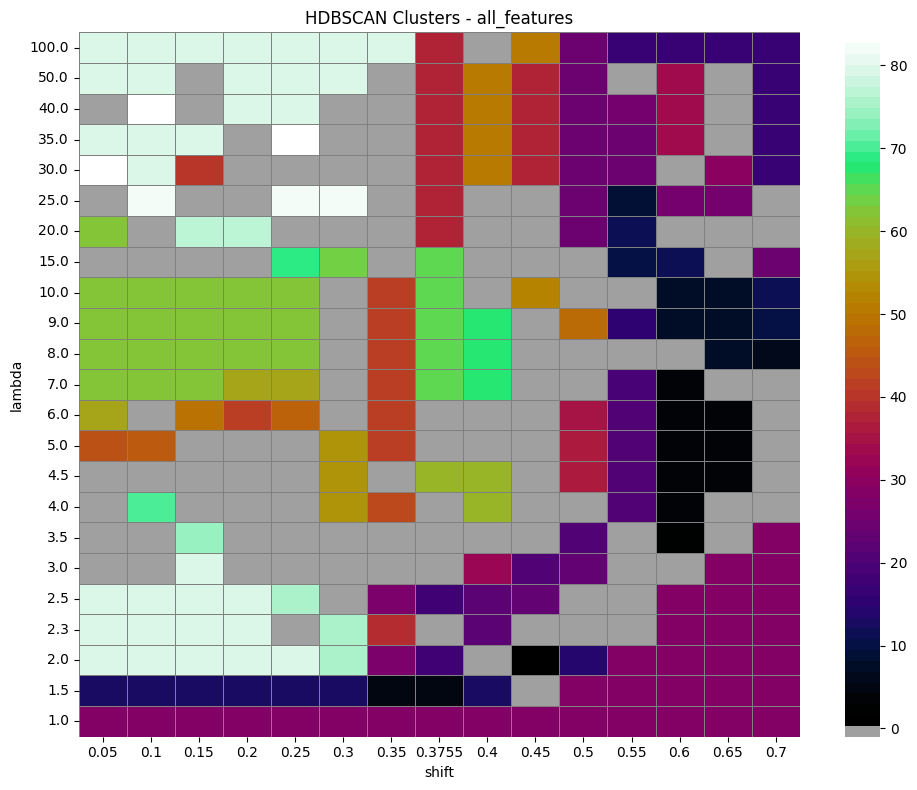

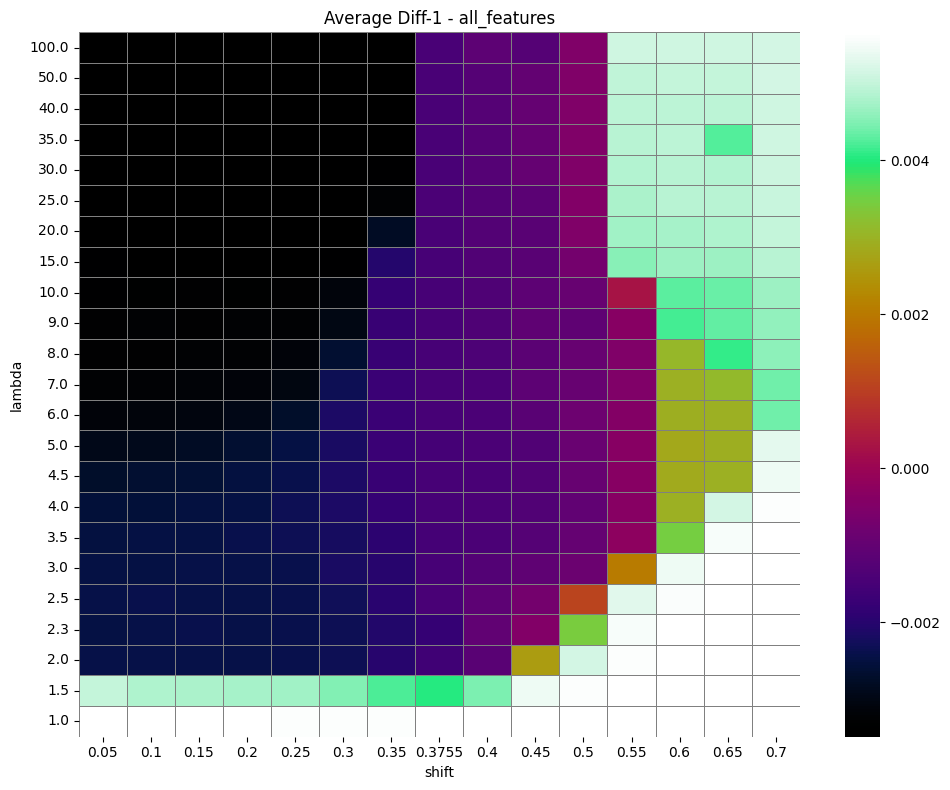


Running: no_functions (groups: ['global'])


/home/karner/.local/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/home/karner/.local/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



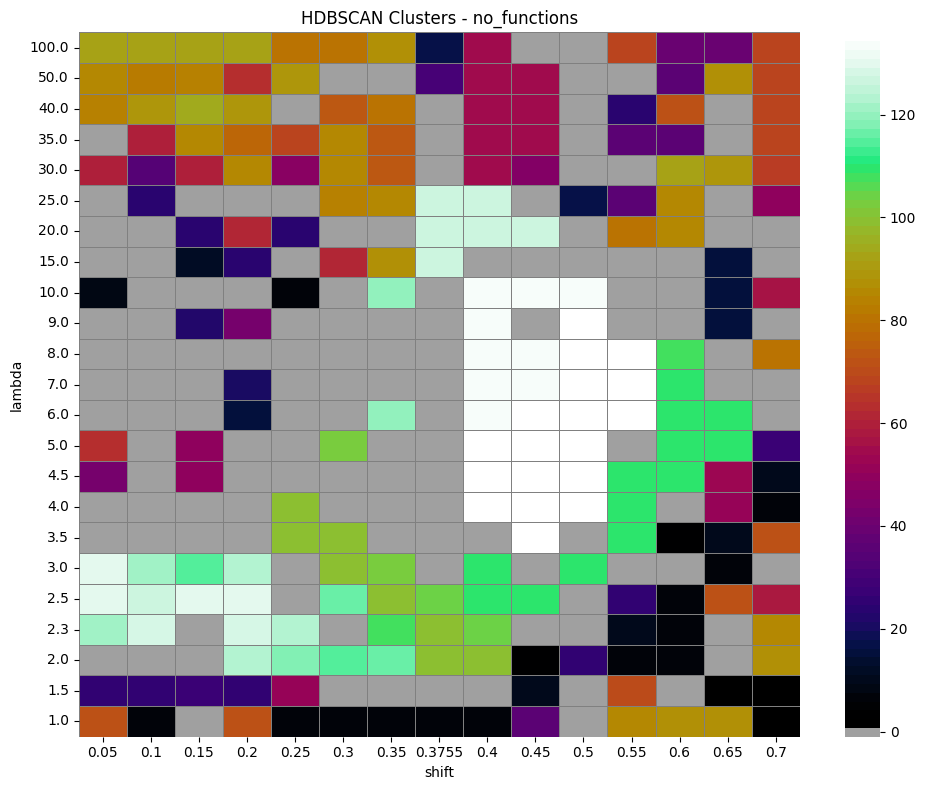

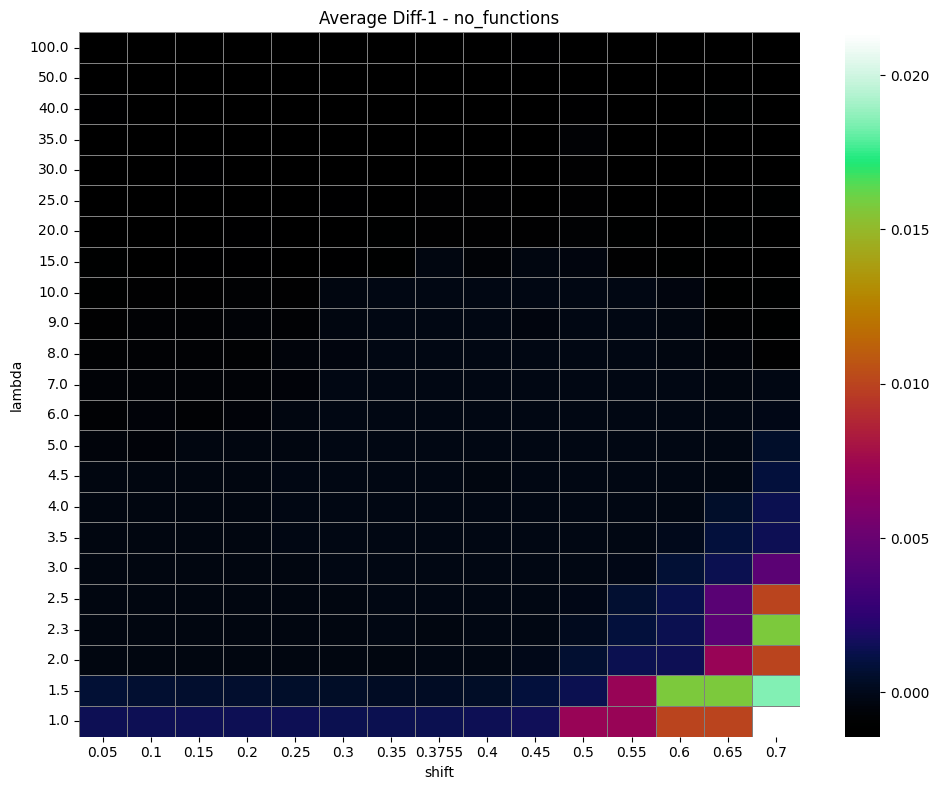


Running: no_orientation_Rg (groups: ['global', 'gofr'])


/home/karner/.local/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/home/karner/.local/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



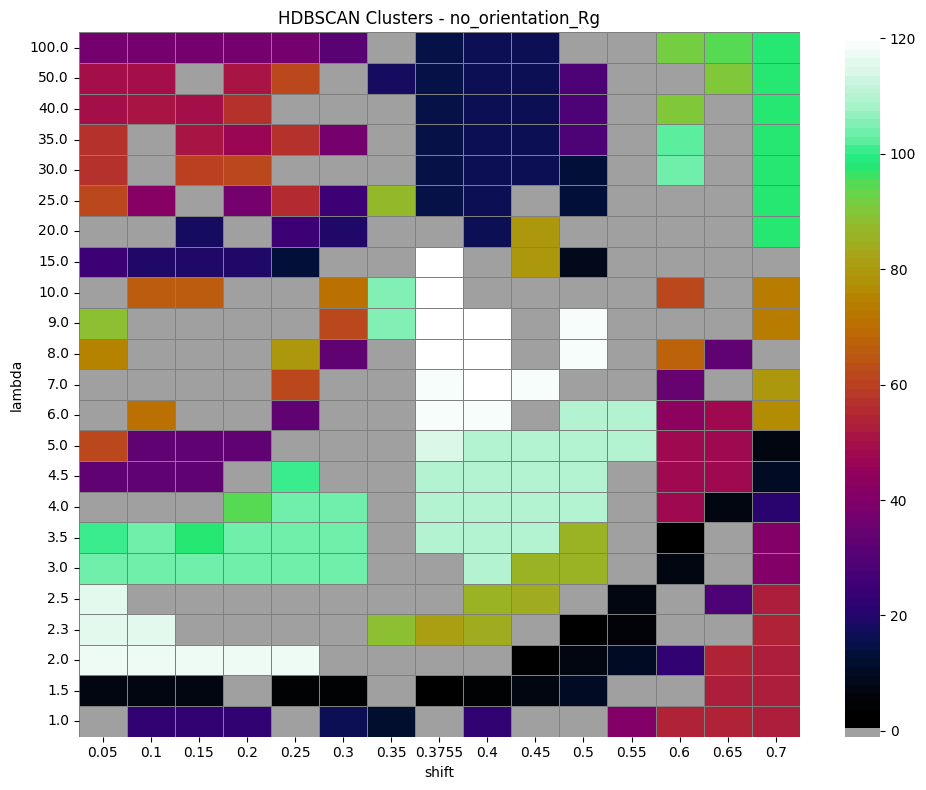

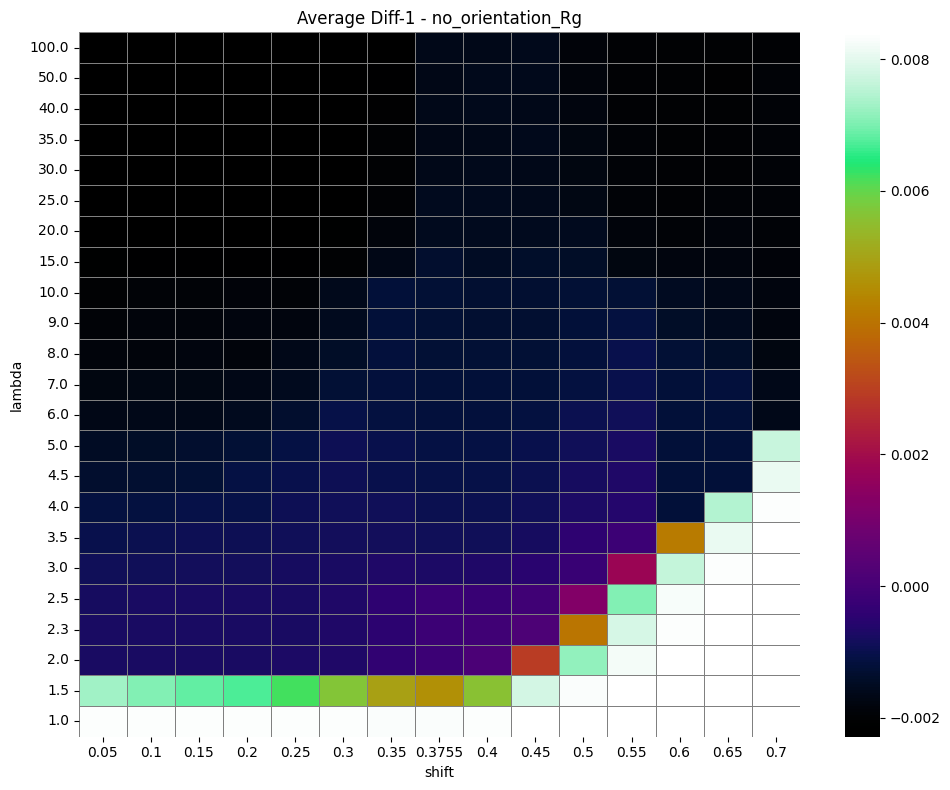


Running: no_orientation_gofr (groups: ['global', 'Rg'])


/home/karner/.local/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/home/karner/.local/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



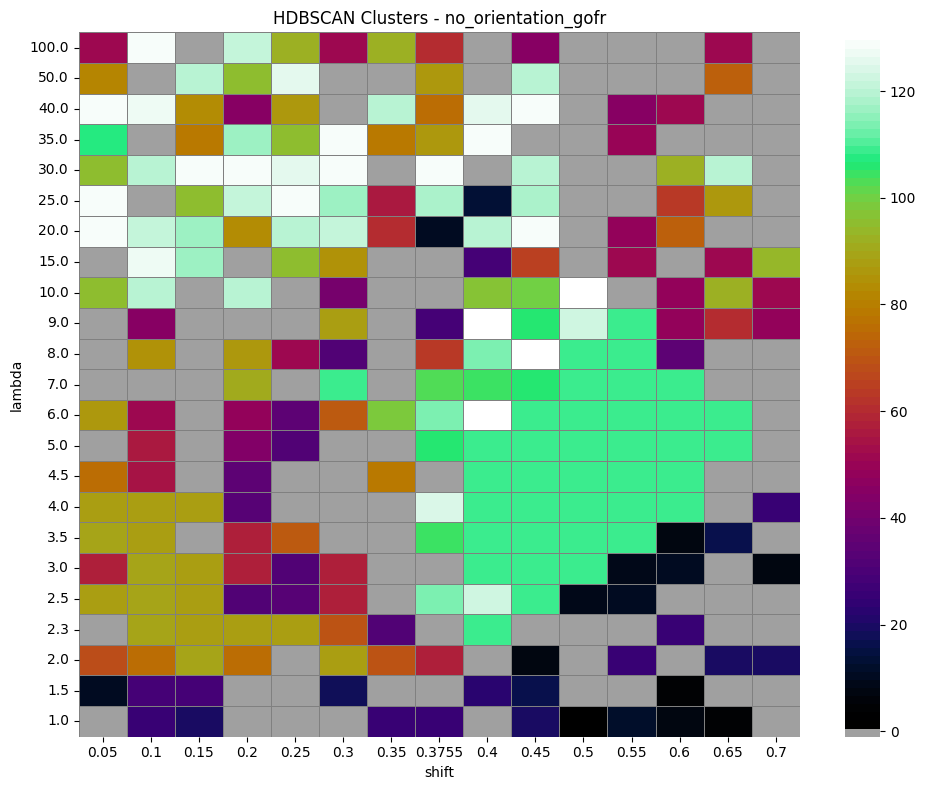

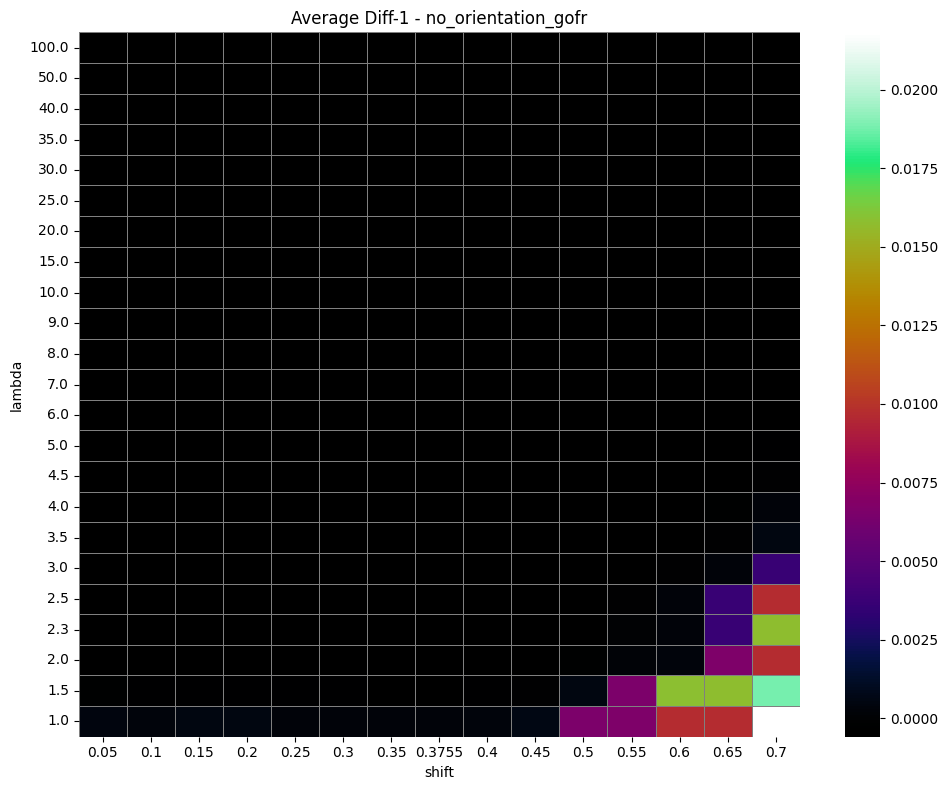


Running: no_Rg_gofr (groups: ['global', 'orientation'])


/home/karner/.local/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/home/karner/.local/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



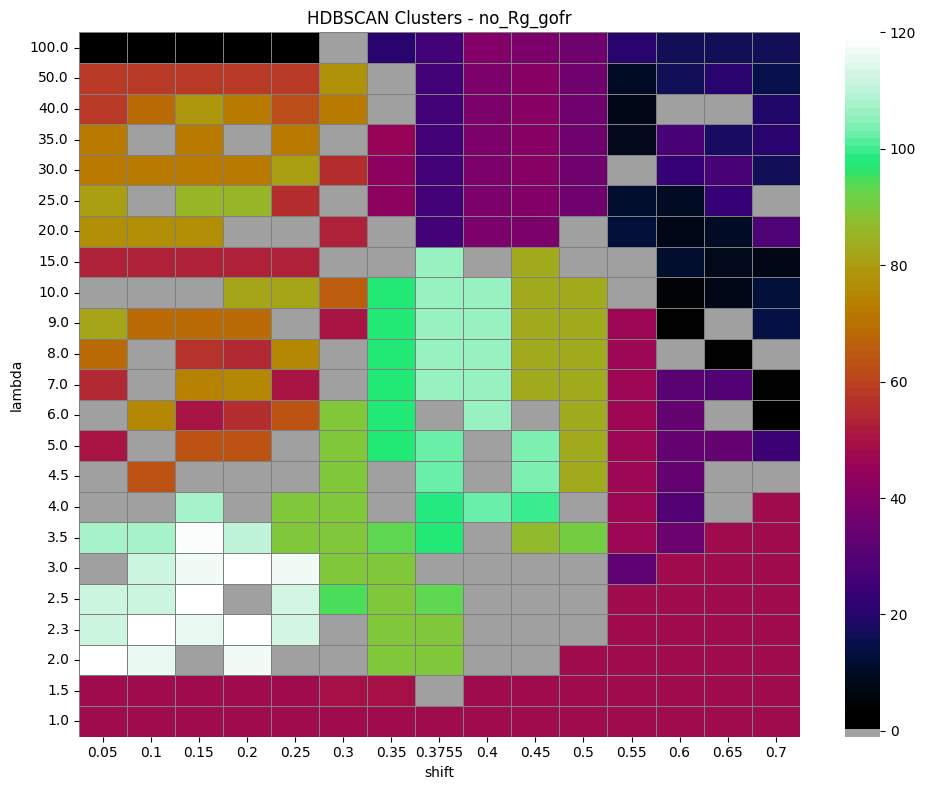

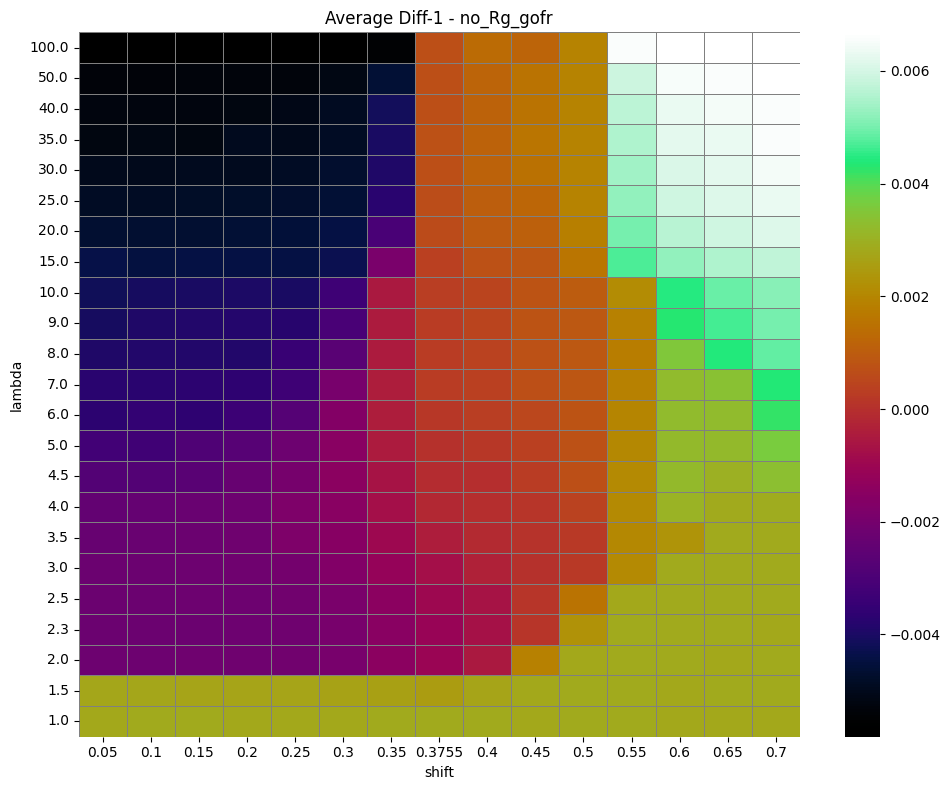


Running: no_global_Rg (groups: ['orientation', 'gofr'])


/home/karner/.local/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/home/karner/.local/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



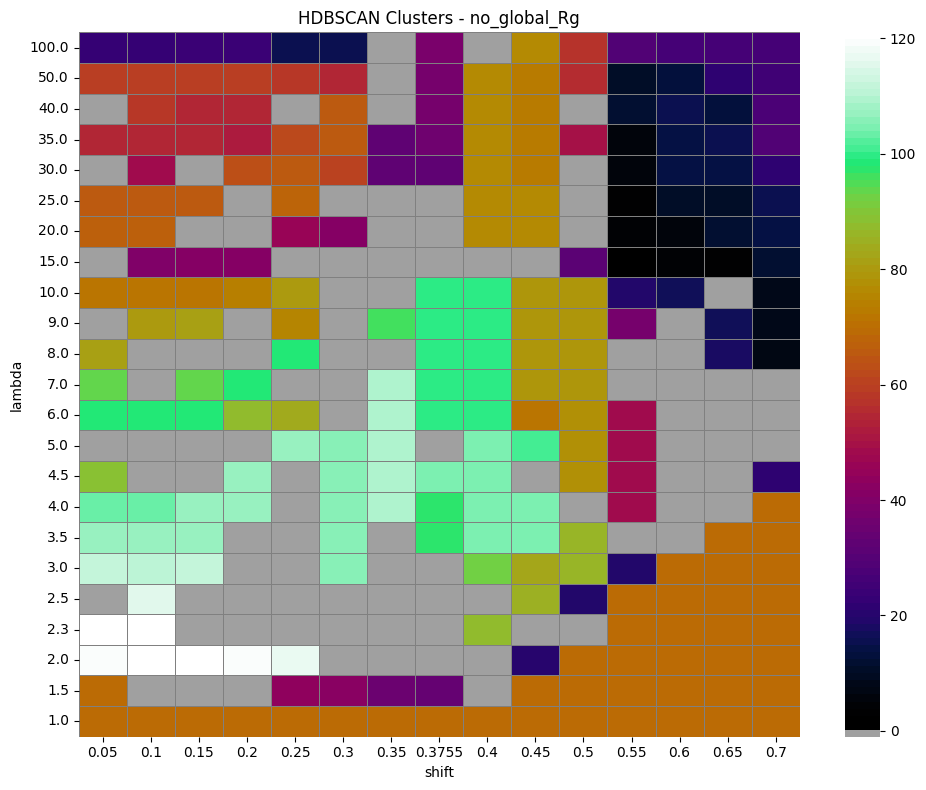

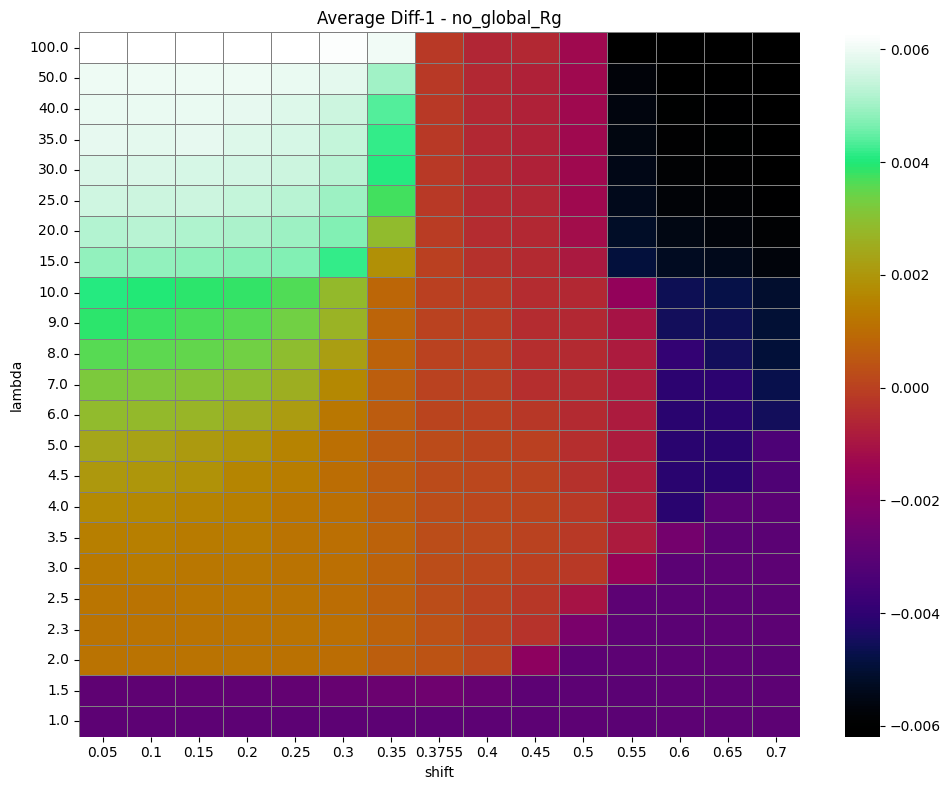


Running: no_orientation (groups: ['global', 'Rg', 'gofr'])


/home/karner/.local/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/home/karner/.local/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



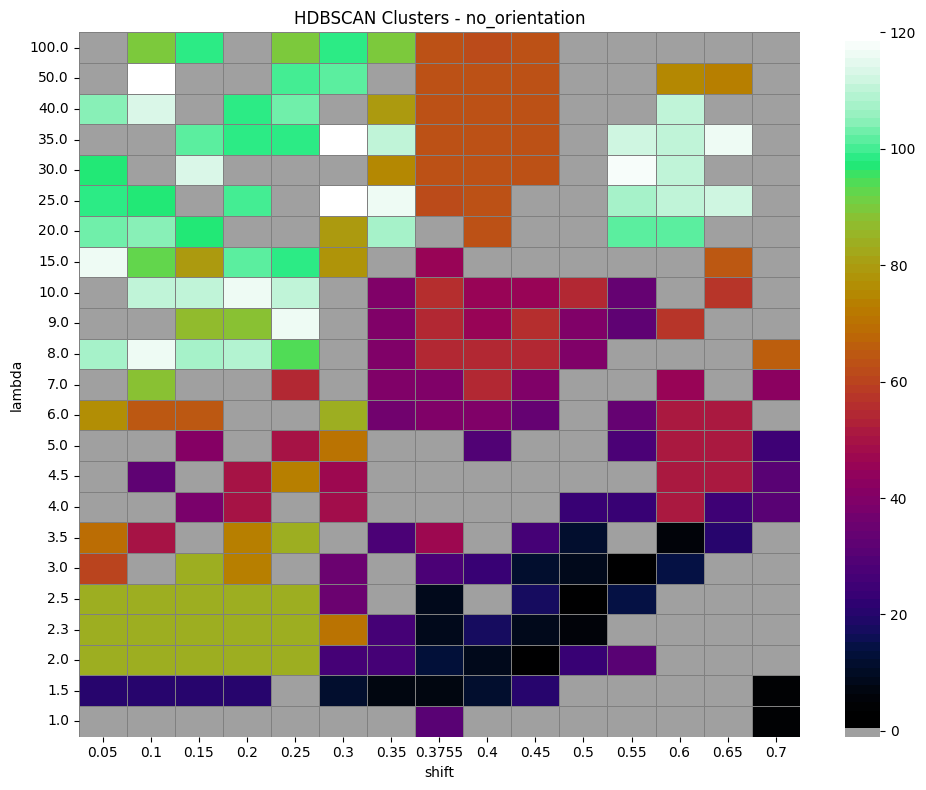

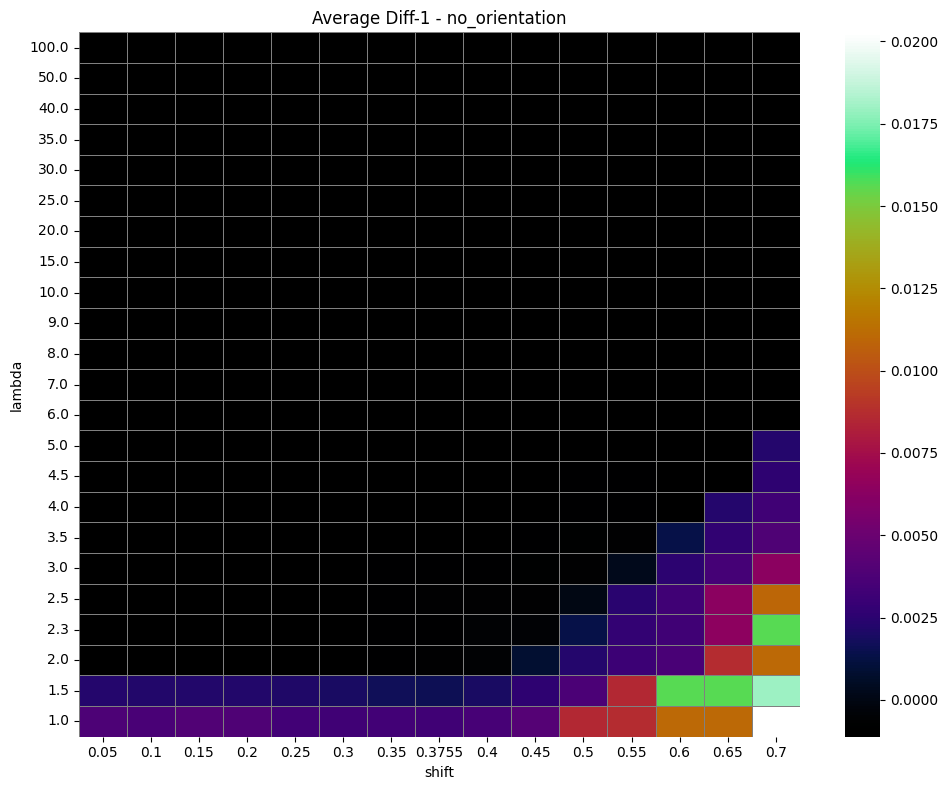


Running: no_Rg (groups: ['global', 'orientation', 'gofr'])


/home/karner/.local/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/home/karner/.local/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



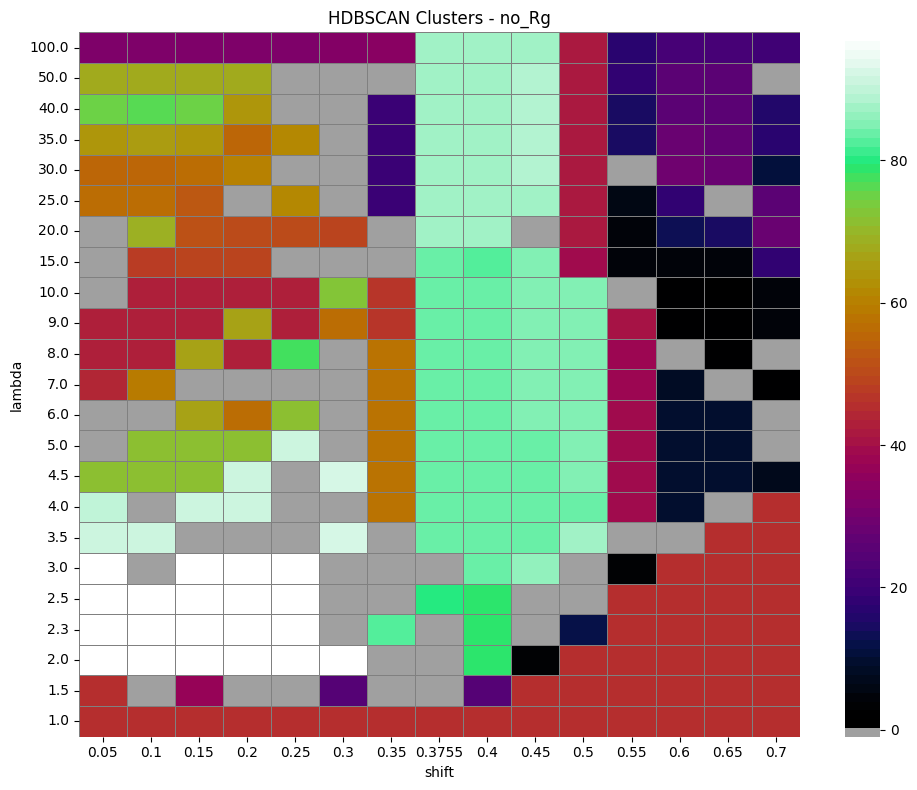

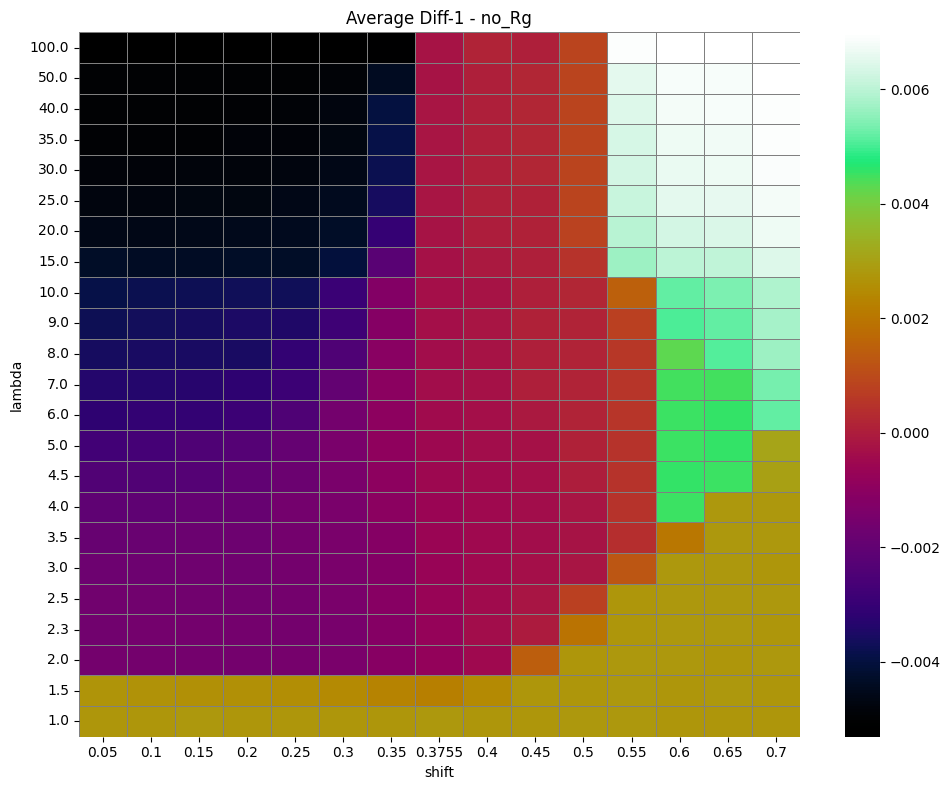

In [5]:
from sklearn.preprocessing import StandardScaler

Shift = df['shift']
Lambda = df['lambda']

results = {}
for name, keep_groups in TEST_SETS.items():
    print(f'\n{"="*60}')
    print(f'Running: {name} (groups: {keep_groups})')
    print(f'{"="*60}')

    feature_cols = [c for g in keep_groups for c in FEATURE_GROUPS[g]]
    X = df[feature_cols].values
    X = StandardScaler().fit_transform(X)

    results[name] = run_diffusion_heatmap(X, Lambda, Shift, set_name=name, cluster_min_size=5)